# Investigating the Scouting MC "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"

## Import and Data

In [1]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist

In [2]:
class ScoutingNanoAODSchema(NanoAODSchema):

    mixins = {
        **NanoAODSchema.mixins,
        "ScoutingJet": "Jet" 
    }

In [11]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:4]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

#uproot.concatenate(file_list)

## Basic Variables

Text(0.5, 0, 'Number of Charged Leptons Per Event')

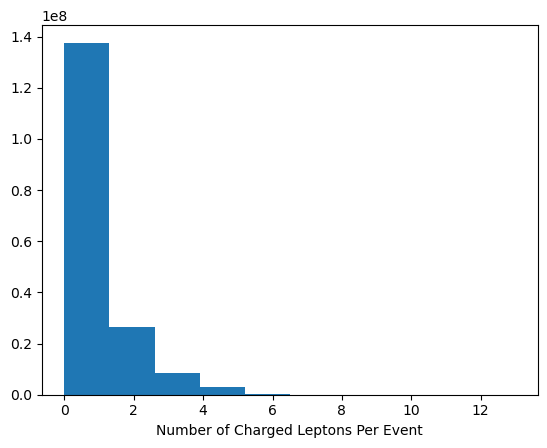

In [40]:
plt.hist(np.add(ak.count(events.ScoutingMuon.pt.compute(),axis=1), ak.count(events.ScoutingElectron.pt.compute(),axis=1)))

plt.xlabel("Number of Charged Leptons Per Event")

Text(0.5, 0, 'Number of Jets Per Event')

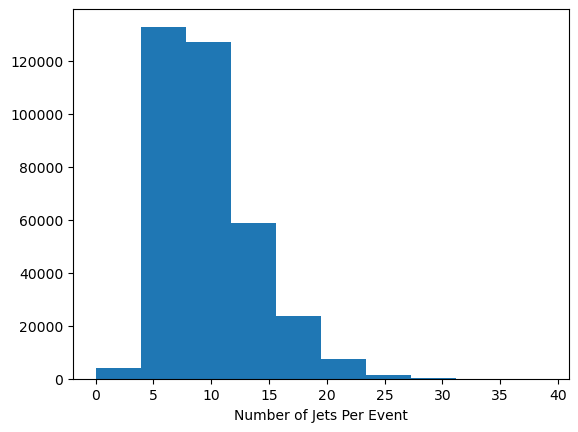

In [26]:
plt.hist(ak.count(small_events.ScoutingJet.pt.compute(),axis=1))

plt.xlabel("Number of Jets Per Event")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4e698f8250>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

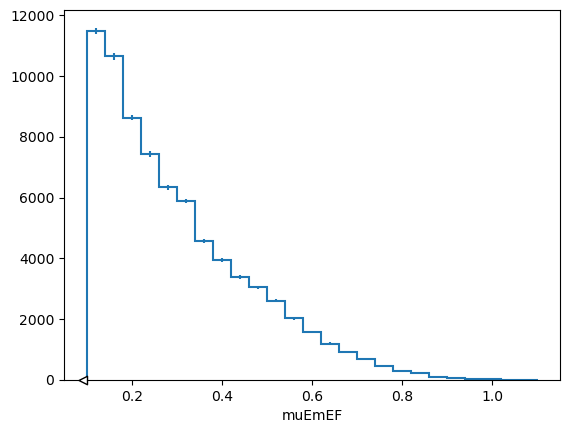

In [81]:
sc_h= Hist(hist.axis.Regular(bins=25, start=0.1, stop=1.1, name="muEmEF"))

sc_h.fill(muEmEF=ak.flatten(small_events.ScoutingJet.muEmEF.compute()))
sc_h.plot1d()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4e6af9dea0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

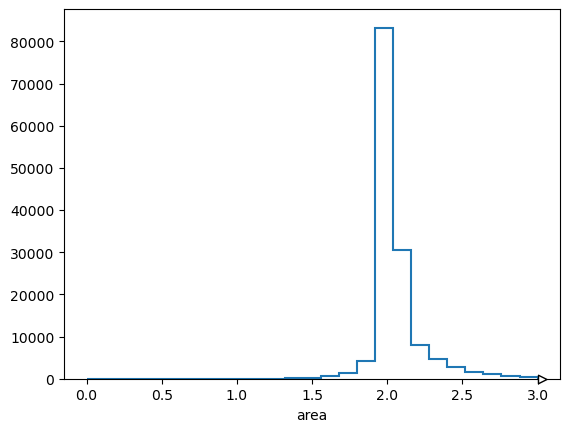

In [85]:
sc_h= Hist(hist.axis.Regular(bins=25, start=0, stop=3, name="area"))

sc_h.fill(area= ak.flatten(small_events.ScoutingFatJet.area.compute()))
sc_h.plot1d()

In [ ]:
small_events.ScoutingJet

## Gen Jet Triplets

### All Triplets

In [7]:
selection = PackedSelection()

selection.add("SixJets", ak.num(small_events.GenJet) > 5)
selection.add("OneB", ak.sum(small_events.GenJet.partonFlavour == 5, axis=1) == 1)
selection.add("OneC", ak.sum(small_events.GenJet.partonFlavour == 4, axis=1) == 1)
selection.add("OneS", ak.sum(small_events.GenJet.partonFlavour == 3, axis=1) == 1)
selection.add("OneAB", ak.sum(small_events.GenJet.partonFlavour == -5, axis=1) == 1)
selection.add("OneAC", ak.sum(small_events.GenJet.partonFlavour == -4, axis=1) == 1)
selection.add("OneAS", ak.sum(small_events.GenJet.partonFlavour == -3, axis=1) == 1)

selection.names


['SixJets', 'OneB', 'OneC', 'OneS', 'OneAB', 'OneAC', 'OneAS']

Text(0.5, 0, 'Mass of all 20 triplets of GenJets [GeV]')

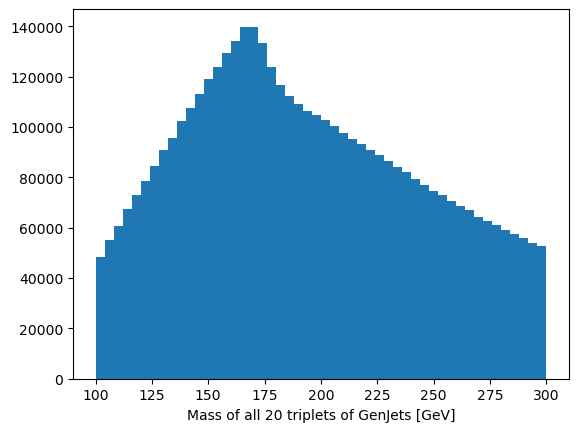

In [8]:
m_events = small_events[selection.all("SixJets")]

arr = []
for comb in iter.combinations(range(6),3):
    j1 = m_events.GenJet[:,comb[0]]
    j2 = m_events.GenJet[:,comb[1]]
    j3 = m_events.GenJet[:,comb[2]]
    arr.append((j1 + j2 + j3).mass.compute())


plt.hist(np.array(arr).flatten(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of all 20 triplets of GenJets [GeV]")

### Specific Flavor Triplets

Text(0.5, 0, 'Mass of b + c + s GenJets [GeV]')

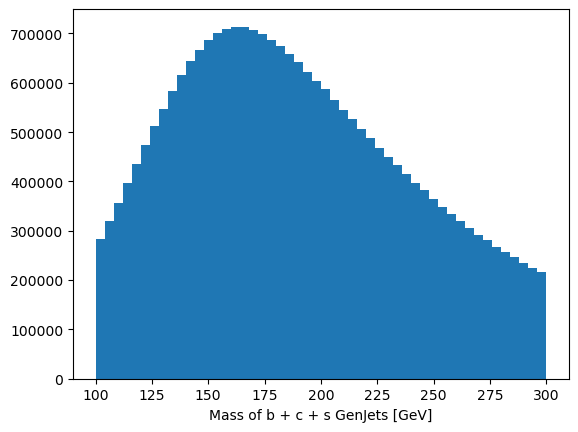

In [10]:
m_events = events[selection.all("OneB", "OneC", "OneS")]

bj = m_events.GenJet[m_events.GenJet.partonFlavour == 5]
cj = m_events.GenJet[m_events.GenJet.partonFlavour == 4]
sj = m_events.GenJet[m_events.GenJet.partonFlavour == 3]


top = bj + cj + sj
plt.hist(top.mass.compute(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of b + c + s GenJets [GeV]")

Text(0.5, 0, 'Mass of b + c + as GenJets [GeV]')

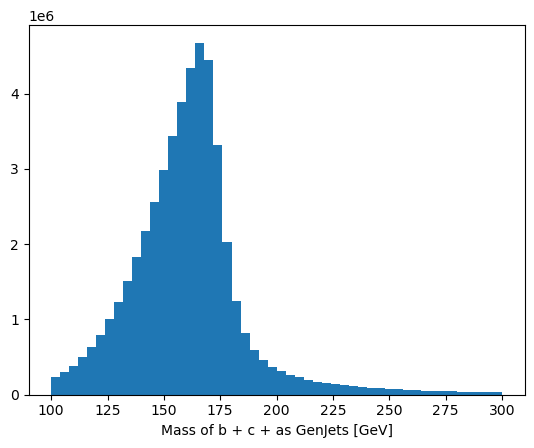

In [12]:
m_events = events[selection.all("OneB", "OneC", "OneAS")]

#I should check this versus the other quark flavor combinations
#and look at the GenPart deltaR method
bj = m_events.GenJet[m_events.GenJet.partonFlavour == 5]
cj = m_events.GenJet[m_events.GenJet.partonFlavour == 4]
asj = m_events.GenJet[m_events.GenJet.partonFlavour == -3]


top = bj + cj + asj
plt.hist(top.mass.compute(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of b + c + as GenJets [GeV]")

## Scouting Jet Triplets

### All Triplets

In [13]:
scouting_selection = PackedSelection()

scouting_selection.add("SixJets", ak.num(small_events.ScoutingJet) > 5)
scouting_selection.add("OneB", ak.sum(small_events.GenJet.partonFlavour == 5, axis=1) == 1)
scouting_selection.add("OneC", ak.sum(small_events.GenJet.partonFlavour == 4, axis=1) == 1)
scouting_selection.add("OneS", ak.sum(small_events.GenJet.partonFlavour == 3, axis=1) == 1)
scouting_selection.add("OneAB", ak.sum(small_events.GenJet.partonFlavour == -5, axis=1) == 1)
scouting_selection.add("OneAC", ak.sum(small_events.GenJet.partonFlavour == -4, axis=1) == 1)
scouting_selection.add("OneAS", ak.sum(small_events.GenJet.partonFlavour == -3, axis=1) == 1)

Text(0.5, 0, 'Mass of all 20 triplets of ScoutingJets [GeV]')

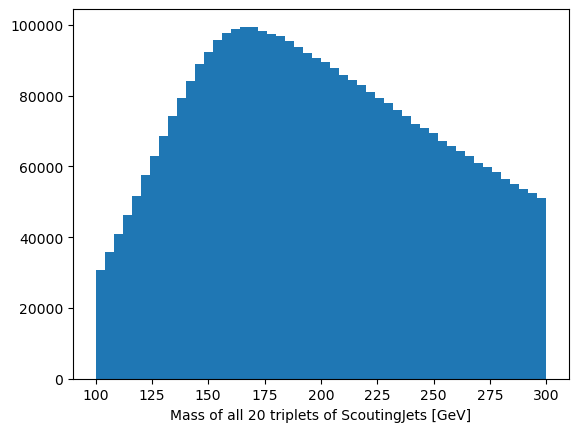

In [14]:
m_events = small_events[scouting_selection.all("SixJets")]


arr = []
for comb in iter.combinations(range(6),3):
    j1 = m_events.ScoutingJet[:,comb[0]]
    j2 = m_events.ScoutingJet[:,comb[1]]
    j3 = m_events.ScoutingJet[:,comb[2]]
    
    arr.append((j1 + j2 + j3).mass.compute())


plt.hist(np.array(arr).flatten(),
         range = (100, 300),
         bins= 50)

plt.xlabel("Mass of all 20 triplets of ScoutingJets [GeV]")


### Specific Flavor Triplets

In [4]:
def triplet_mass_from_flavor(ev, i, j, k):
    selector = PackedSelection()
    selector.add("ThreeJets", ak.num(ev.ScoutingJet) > 2)
    selector.add("OneMatchI", ak.sum(ev.ScoutingJet.nearest(ev.GenJet).partonFlavour == i, axis=1) == 1)
    selector.add("OneMatchJ", ak.sum(ev.ScoutingJet.nearest(ev.GenJet).partonFlavour == j, axis=1) == 1)
    selector.add("OneMatchK", ak.sum(ev.ScoutingJet.nearest(ev.GenJet).partonFlavour == k, axis=1) == 1)
    
    m_ev = ev[selector.all("ThreeJets","OneMatchI","OneMatchJ","OneMatchK")]

    #m_ev = m_ev[0:20]
    aj = m_ev.ScoutingJet[m_ev.ScoutingJet.nearest(m_ev.GenJet).partonFlavour == i]
    bj = m_ev.ScoutingJet[m_ev.ScoutingJet.nearest(m_ev.GenJet).partonFlavour == j]
    cj = m_ev.ScoutingJet[m_ev.ScoutingJet.nearest(m_ev.GenJet).partonFlavour == k]
    return ak.flatten((aj + bj + cj).mass)

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ebd819630>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

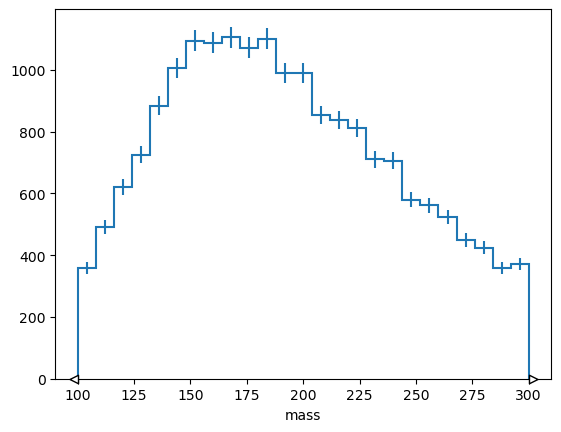

In [17]:
sc_wrong = Hist(hist.axis.Regular(bins=25, start=100, stop=300, name="mass"))

sc_wrong.fill(mass=triplet_mass_from_flavor(small_events,3,4,5).compute())
sc_wrong.plot1d()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4e97f0b5b0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

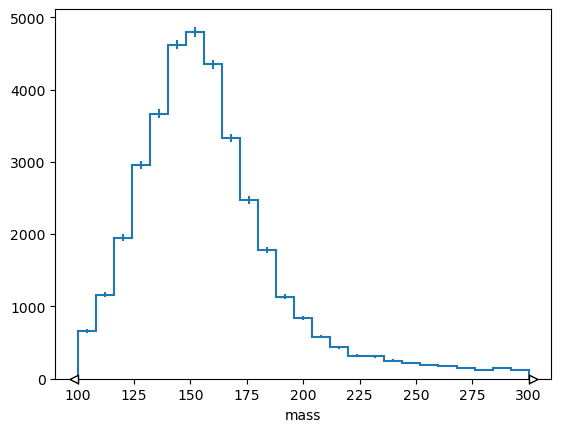

In [18]:
sc_right= Hist(hist.axis.Regular(bins=25, start=100, stop=300, name="mass"))

sc_right.fill(mass=triplet_mass_from_flavor(small_events,-3,4,5).compute())
sc_right.plot1d()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ebe489ba0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

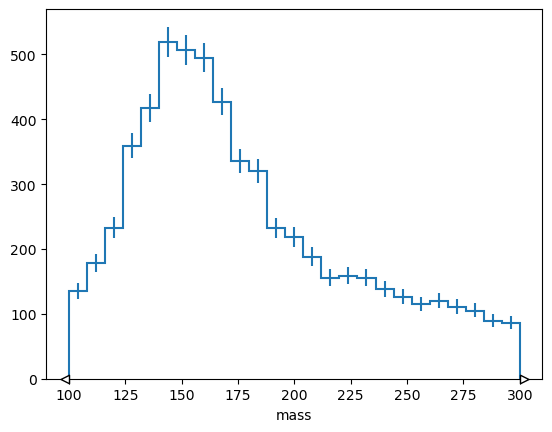

In [20]:
sc_wrong = Hist(hist.axis.Regular(bins=25, start=100, stop=300, name="mass"))

sc_wrong.fill(mass=triplet_mass_from_flavor(small_events,-1,4,5).compute())
sc_wrong.plot1d()

In [27]:
triplet_flavor_hists = {}
for comb in iter.combinations([1,-1,2,-2,3,-3,4,-4,5,-5],3):
    sc_h= Hist(hist.axis.Regular(bins=25, start=100, stop=300, name="mass"))
    sc_h.fill(mass=triplet_mass_from_flavor(small_events,comb[0],comb[1],comb[2]).compute())
    triplet_flavor_hists[str(comb[0]) + "_" + str(comb[1]) + "_" + str(comb[2])] = sc_h
    print(str(comb[0]) + "_" + str(comb[1]) + "_" + str(comb[2]))

1_-1_2
1_-1_-2
1_-1_3
1_-1_-3
1_-1_4
1_-1_-4
1_-1_5
1_-1_-5
1_2_-2
1_2_3
1_2_-3
1_2_4
1_2_-4
1_2_5
1_2_-5
1_-2_3
1_-2_-3
1_-2_4
1_-2_-4
1_-2_5
1_-2_-5
1_3_-3
1_3_4
1_3_-4
1_3_5
1_3_-5
1_-3_4
1_-3_-4
1_-3_5
1_-3_-5
1_4_-4
1_4_5
1_4_-5
1_-4_5
1_-4_-5
1_5_-5
-1_2_-2
-1_2_3
-1_2_-3
-1_2_4
-1_2_-4
-1_2_5
-1_2_-5
-1_-2_3
-1_-2_-3
-1_-2_4
-1_-2_-4
-1_-2_5
-1_-2_-5
-1_3_-3
-1_3_4
-1_3_-4
-1_3_5
-1_3_-5
-1_-3_4
-1_-3_-4
-1_-3_5
-1_-3_-5
-1_4_-4
-1_4_5
-1_4_-5
-1_-4_5
-1_-4_-5
-1_5_-5
2_-2_3
2_-2_-3
2_-2_4
2_-2_-4
2_-2_5
2_-2_-5
2_3_-3
2_3_4
2_3_-4
2_3_5
2_3_-5
2_-3_4
2_-3_-4
2_-3_5
2_-3_-5
2_4_-4
2_4_5
2_4_-5
2_-4_5
2_-4_-5
2_5_-5
-2_3_-3
-2_3_4
-2_3_-4
-2_3_5
-2_3_-5
-2_-3_4
-2_-3_-4
-2_-3_5
-2_-3_-5
-2_4_-4
-2_4_5
-2_4_-5
-2_-4_5
-2_-4_-5
-2_5_-5
3_-3_4
3_-3_-4
3_-3_5
3_-3_-5
3_4_-4
3_4_5
3_4_-5
3_-4_5
3_-4_-5
3_5_-5
-3_4_-4
-3_4_5
-3_4_-5
-3_-4_5
-3_-4_-5
-3_5_-5
4_-4_5
4_-4_-5
4_5_-5
-4_5_-5


In [54]:
dir(triplet_flavor_hists["3_-4_-5"])

['T',
 '__add__',
 '__annotations__',
 '__array__',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__itruediv__',
 '__le__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_axis',
 '_clone',
 '_compute_commonindex',
 '_compute_inplace_op',
 '_compute_uhi_index',
 '_export_bh_',
 '_family',
 '_from_histogram_cpp',
 '_from_histogram_object',
 '_generate_axes_',
 '_hist',
 '_import_bh_',
 '_index_transform',
 '_loc_shortcut',
 '_name_to_index',
 '_new_hist',
 '_reduce',
 '_repr_html_',
 '_

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015f040>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015f130>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015ce50>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015d420>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015f7c0>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015d600>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015e5c0>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4ef015c400>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f4e8c60b820>, e

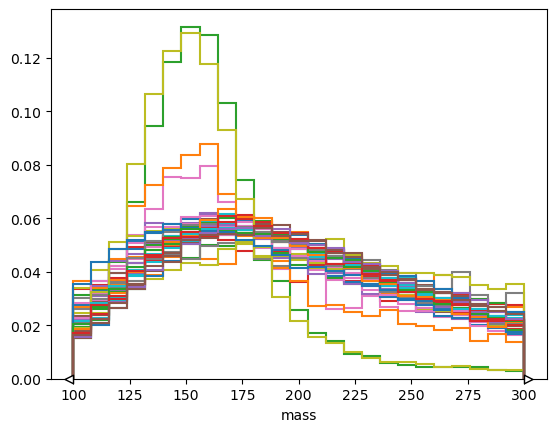

In [63]:
#["-3_4_5","2_-3_5","-1_2_5","-1_4_5"]
filtered_triplets = {k:v/(np.sum(v.counts())) for k,v in triplet_flavor_hists.items() if "_-5" in k}
total = hist.Stack.from_dict(filtered_triplets)
total.plot()